In [1]:
# ✅ Basic Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8')
sns.set()

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


Mean Absolute Error: 0.0468
R² Score: 0.1338


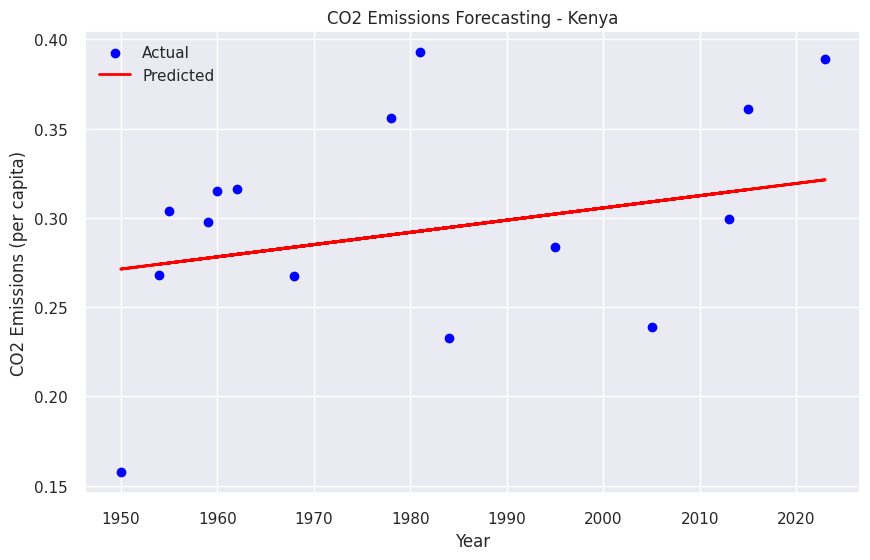

In [28]:
# Importing dependencies
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

#  Loading dataset
kenya_df = pd.read_csv('kenya_co2.csv')  # <-- make sure file name matches

kenya_df.columns = kenya_df.columns.str.strip()
kenya_df.rename(columns={
    'Entity': 'Country',
    'Year': 'Year',
    'Annual CO₂ emissions (per capita)': 'CO2_per_capita'
}, inplace=True)

#   columns to numeric
kenya_df['Year'] = pd.to_numeric(kenya_df['Year'], errors='coerce')
kenya_df['CO2_per_capita'] = pd.to_numeric(kenya_df['CO2_per_capita'], errors='coerce')

# Drop rows with any missing values
kenya_df = kenya_df.dropna()

# features and target
X = kenya_df[['Year']]  # independent variable
y = kenya_df['CO2_per_capita']  # dependent variable

#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialization and training the model
model = LinearRegression()
model.fit(X_train, y_train)

# make prediction
y_pred = model.predict(X_test)

# evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Visualize the result
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (per capita)')
plt.title('CO2 Emissions Forecasting - Kenya')
plt.legend()
plt.show()


In [29]:
# Making A forecast
future_years = np.array(range(2025, 2051)).reshape(-1, 1)

future_predictions = model.predict(future_years)

forecast_df = pd.DataFrame({
    'Year': future_years.flatten(),
    'Predicted_CO2_per_capita': future_predictions
})

print(forecast_df.head(10))  # show first 10 forecasts


   Year  Predicted_CO2_per_capita
0  2025                  0.322733
1  2026                  0.323418
2  2027                  0.324103
3  2028                  0.324788
4  2029                  0.325473
5  2030                  0.326158
6  2031                  0.326844
7  2032                  0.327529
8  2033                  0.328214
9  2034                  0.328899


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
